# FREIGHT PRICING ANALYSIS

# Business Understanding

Forecasting future outcomes is a core competitive advantage in any industry where decisions must be locked in before conditions are fully known. Businesses that can anticipate price movements, demand shifts, or cost changes are able to act ahead of competitors — stocking up before a price increase, liquidating inventory before a decline, or pricing a product correctly before a peak season hits.

This advantage comes from studying historical patterns: past behavior in prices, demand, and market conditions tends to carry predictive signal about what comes next. Predictive modeling formalizes this — by processing historical data and identifying the relationships that drive an outcome, we can estimate future values with a quantifiable degree of confidence, and use that estimate to inform decisions made today.

This is especially valuable in cost-sensitive, competitive industries such as freight and logistics, where shipping costs directly affect how a business prices its own products.

## Problem Statement


---
ABC Enterprises wants to forecast shipping costs for the month of December. Historical shipping data is available, including vehicle/equipment type, load weight, distance, shipping date, and the associated cost for each shipment.

December is a peak holiday shipping season, and ABC Enterprises wants to use this forecast to plan a shipping pricing strategy for its own customers — for example, deciding where it can afford to offer free or discounted shipping without eroding margin.



## Objectives
The objective of this analysis is to:

1. Identify which variables (distance, weight, equipment type, market conditions, date/seasonality) most strongly influence shipping cost.


2. Build a model that accurately predicts December shipping costs based on these variables.

Use these predictions to support a shipping pricing/discount structure that protects ABC Enterprises' margins while remaining attractive to customers during the holiday season.


---




## Success criteria

1.Identify the variables most strongly associated with freight cost, ranked by correlation and feature importance, to understand what drives pricing.

2. Select the best-performing regression model for predicting freight cost, evaluated using R², RMSE, and MAPE — targeting an R² above 0.90

3. Achieve price predictions within 10% of actual cost on average, so the model's output is reliable enough to inform a real pricing/discount strategy.



# Data understanding
The data seems to have been split between train and test data

In [241]:
#importing libraries to support in data understanding and cleaning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from math import sqrt
from sklearn.metrics import mean_squared_error


warnings.filterwarnings('ignore')

In [242]:
# importing the files
freight = pd.read_csv('train-test.csv')
validation=pd.read_csv('validation.csv')
december=pd.read_csv('december-chart-inputs.csv')
validation_pred = pd.read_csv('validation-predictions-template.csv')

In [243]:
freight.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [244]:
validation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       12000 non-null  object 
 1   pickup        12000 non-null  object 
 2   delivery      12000 non-null  object 
 3   pickup_lat    12000 non-null  float64
 4   pickup_lon    12000 non-null  float64
 5   delivery_lat  12000 non-null  float64
 6   delivery_lon  12000 non-null  float64
 7   distance      12000 non-null  float64
 8   equipment     12000 non-null  object 
 9   weight        11835 non-null  float64
 10  date          12000 non-null  object 
 11  market_index  11751 non-null  float64
 12  quote_signal  12000 non-null  float64
dtypes: float64(8), object(5)
memory usage: 1.2+ MB


In [245]:
#summary statistics
freight.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


The statistics give a lot descriptive analysis. we can tell;
1. The weight has a -ve value which is not accurate which will distort mean value
2. Count is not equal for all columns so there is some missing data
3. The mean of the distance is closer to the 75% percentile mean the data is more right skewed meaning most of the distances are to medium.
4. The quote signal seem to be close to the 50% which means it may be evenly distributed however the market_signal and posted_rate seem more right skewed

In [246]:
validation.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11835.000000,11751.000000,12000.000000
mean,35.574216,-90.724880,35.609538,-90.913530,1141.773100,30506.636248,0.926913,2.051334
std,4.366999,13.411638,4.351844,13.624744,732.333797,10572.590450,0.074109,0.219804
min,25.500000,-121.698490,25.500000,-121.698490,70.000000,-47500.000000,0.723610,1.234760
25%,31.986910,-97.226810,32.009290,-98.400590,556.100000,25493.000000,0.863880,1.903467
50%,35.294790,-87.528710,35.294790,-87.528710,953.600000,31193.000000,0.922900,2.051230
75%,39.411040,-82.783790,39.411040,-82.783790,1670.500000,36843.500000,0.992355,2.200030
max,44.302960,-69.500000,44.302960,-69.500000,3325.700000,47500.000000,1.098950,2.896350


Similar characteristics to the freight data set meaning cleaning needs to be done for both data sets for accurate outputs

#Data Cleaning

Handling null values

Dropping duplicates

Display and Clean Outliers



In [247]:
#checking for data types per column
freight.dtypes

,0
load_id,object
pickup,object
delivery,object
pickup_lat,float64
pickup_lon,float64
delivery_lat,float64
delivery_lon,float64
distance,float64
equipment,object
weight,float64


In [248]:
validation.dtypes

,0
load_id,object
pickup,object
delivery,object
pickup_lat,float64
pickup_lon,float64
delivery_lat,float64
delivery_lon,float64
distance,float64
equipment,object
weight,float64


In [249]:
#converting date column to time format
freight['date'] = pd.to_datetime(freight['date'])

In [250]:
#converting date column to time format
validation['date'] = pd.to_datetime(validation['date'])

In [251]:
#checking for null/empty values per column
freight.isnull().sum()

,0
load_id,0
pickup,0
delivery,0
pickup_lat,0
pickup_lon,0
delivery_lat,0
delivery_lon,0
distance,0
equipment,0
weight,300


The weight and market and index column have some missing data.
The missing data is 0.7% of the total data

Since the 2 columns seem to be right skewed based on the statistical table above, it is better to fill with the median since a very small percentage of the data will be affected


In [252]:

freight['weight'] = freight['weight'].fillna(freight['weight'].median())
freight['market_index'] = freight['market_index'].fillna(freight['market_index'].median())

In [253]:
freight.isnull().sum()


,0
load_id,0
pickup,0
delivery,0
pickup_lat,0
pickup_lon,0
delivery_lat,0
delivery_lon,0
distance,0
equipment,0
weight,0


In [254]:
validation.isnull().sum()

,0
load_id,0
pickup,0
delivery,0
pickup_lat,0
pickup_lon,0
delivery_lat,0
delivery_lon,0
distance,0
equipment,0
weight,165


There is also some missing data also on weight and market index on the validation data set. The missing data is atleast 3% of the total data

Since the 2 columns seem to be right skewed based on the statistical table above, it is better to fill with the median since a very small percentage of the data will be affected

In [255]:
validation['weight'] = validation['weight'].fillna(validation['weight'].median())
validation['market_index'] = validation['market_index'].fillna(validation['market_index'].median())

In [256]:
validation.isnull().sum()

,0
load_id,0
pickup,0
delivery,0
pickup_lat,0
pickup_lon,0
delivery_lat,0
delivery_lon,0
distance,0
equipment,0
weight,0


In [257]:
# checking duplicates
freight.duplicated().sum()

np.int64(0)

In [258]:
# checking duplicates
validation.duplicated().sum()

np.int64(0)

In [259]:
# checking duplicates
validation_pred.duplicated().sum()

np.int64(0)

In [260]:
#checking for negative values on weight column
(freight['weight'] < 0).sum()

np.int64(292)

In [261]:

freight[freight['weight']<0]

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
68,TR-000069,Amarillo,Dayton,33.17137,-104.36789,39.87206,-85.62931,1334.2,Reefer,-36559.0,2025-01-01,0.96102,2.11777,2831.27
204,TR-000205,Fresno,Tucson,33.07921,-119.79528,30.92733,-113.23037,496.2,Dry Van,-26670.0,2025-01-02,0.96903,2.13155,1046.92
206,TR-000207,Columbia,Raleigh,34.63570,-83.28506,35.37376,-77.47605,411.3,Reefer,-20003.0,2025-01-02,0.94800,2.31682,959.15
225,TR-000226,Greensboro,Lubbock,35.98195,-82.78379,29.87534,-99.85456,1317.4,Reefer,-23981.0,2025-01-02,1.00820,2.13918,2836.00
376,TR-000377,Madison,Providence,41.70243,-89.85588,37.37287,-69.50000,1331.1,Dry Van,-41397.0,2025-01-03,0.94787,1.91867,2522.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47404,TR-047405,Baton Rouge,Memphis,30.50134,-92.65374,35.56802,-89.52871,468.7,Dry Van,-24142.0,2025-10-28,0.94219,1.83201,1077.64
47431,TR-047432,Phoenix,Chattanooga,28.75668,-115.87725,35.29792,-87.18651,1978.6,Flatbed,-35617.0,2025-10-28,0.92870,2.00708,4295.45
47735,TR-047736,Houston,Reno,30.71157,-94.76550,39.54838,-118.64843,1689.1,Reefer,-43951.0,2025-10-30,1.04615,1.85824,3933.12
47850,TR-047851,Shreveport,Cincinnati,32.54628,-92.31888,37.15706,-86.77499,538.3,Dry Van,-28144.0,2025-10-31,0.98093,1.86958,1191.61


In [262]:
#converting the negative values absolute
freight['weight'] = freight['weight'].abs()

In [263]:
freight.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000,48000.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31417.369563,2025-05-31 19:53:29.400000,1.083172,2.062468,2373.980682
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,5000.000000,2025-01-01 00:00:00,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25961.000000,2025-03-18 00:00:00,0.950610,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31438.000000,2025-05-31 00:00:00,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,2025-08-15 00:00:00,1.218525,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,2025-10-31 00:00:00,1.467780,3.610350,25533.000000
std,4.315285,13.482431,4.317199,13.476589,728.564416,7971.486742,NaN,0.167452,0.291391,1486.493245


In [264]:
#checking for negative values on weight column
(validation['weight'] < 0).sum()

np.int64(145)

In [265]:
validation[validation['weight'] < 0]

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
183,TE-000184,New York,Boston,40.00674,-73.79840,39.27463,-69.50000,278.7,Dry Van,-36522.0,2025-11-01,0.86676,1.76257
205,TE-000206,Columbia,Indianapolis,34.63570,-83.28506,38.52567,-88.85948,487.4,Dry Van,-25784.0,2025-11-01,0.90519,2.13603
357,TE-000358,Los Angeles,New York,28.56624,-116.70249,40.00674,-73.79840,2869.8,Flatbed,-32517.0,2025-11-02,0.80113,1.99922
361,TE-000362,Oklahoma City,Atlanta,31.88294,-98.58097,34.84933,-86.28940,844.8,Flatbed,-32011.0,2025-11-02,0.81491,1.55426
408,TE-000409,Little Rock,Cincinnati,34.27518,-92.06214,37.15706,-86.77499,446.3,Dry Van,-35044.0,2025-11-03,0.84866,1.98759
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11599,TE-011600,Lexington,San Francisco,36.99152,-84.99876,35.19670,-121.69849,2348.7,Dry Van,-37140.0,2025-12-30,0.96417,1.99567
11652,TE-011653,Jackson,Toledo,32.07771,-90.92587,41.97663,-84.45902,920.7,Dry Van,-24484.0,2025-12-30,0.97043,2.01696
11658,TE-011659,Raleigh,Tucson,35.37376,-77.47605,30.92733,-113.23037,2412.4,Reefer,-44860.0,2025-12-30,0.94776,2.03311
11900,TE-011901,New Orleans,Jacksonville,32.53273,-92.19519,31.98691,-84.48897,530.7,Reefer,-42225.0,2025-12-31,0.97828,2.09222


In [266]:
#converting the negative values absolute
validation['weight'] = validation['weight'].abs()

In [267]:
validation.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.00000,12000,12000.000000,12000.000000
mean,35.574216,-90.724880,35.609538,-90.913530,1141.773100,31281.71775,2025-12-01 02:30:28.800000256,0.926830,2.051334
min,25.500000,-121.698490,25.500000,-121.698490,70.000000,5000.00000,2025-11-01 00:00:00,0.723610,1.234760
25%,31.986910,-97.226810,32.009290,-98.400590,556.100000,25823.50000,2025-11-16 00:00:00,0.865145,1.903467
50%,35.294790,-87.528710,35.294790,-87.528710,953.600000,31193.00000,2025-12-01 00:00:00,0.922900,2.051230
75%,39.411040,-82.783790,39.411040,-82.783790,1670.500000,36844.75000,2025-12-16 00:00:00,0.991390,2.200030
max,44.302960,-69.500000,44.302960,-69.500000,3325.700000,47500.00000,2025-12-31 00:00:00,1.098950,2.896350
std,4.366999,13.411638,4.351844,13.624744,732.333797,7932.83731,NaN,0.073339,0.219804


The negative sign removed on both validation and freight data sets to give more accurate statistics

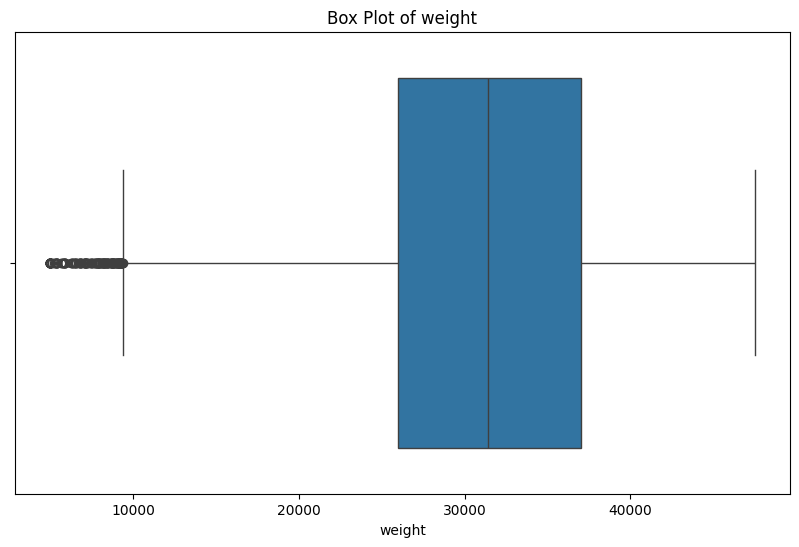

In [268]:
# plotting outliers for weight column
plt.figure(figsize=(10, 6))
sns.boxplot(x=freight['weight'])
plt.title('Box Plot of weight')
plt.show()

Weight column does not seem to have a lot of outliers

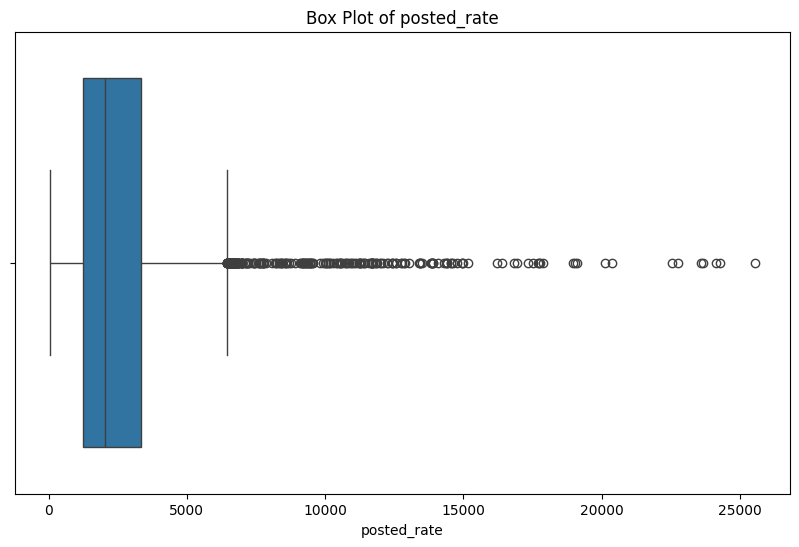

In [269]:
# plot outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=freight['posted_rate'])
plt.title('Box Plot of posted_rate')
plt.show()

Posted_rate seems to have the highest number of outliers, however we need more plots and data analysis to determine the action to be taken on posted rate

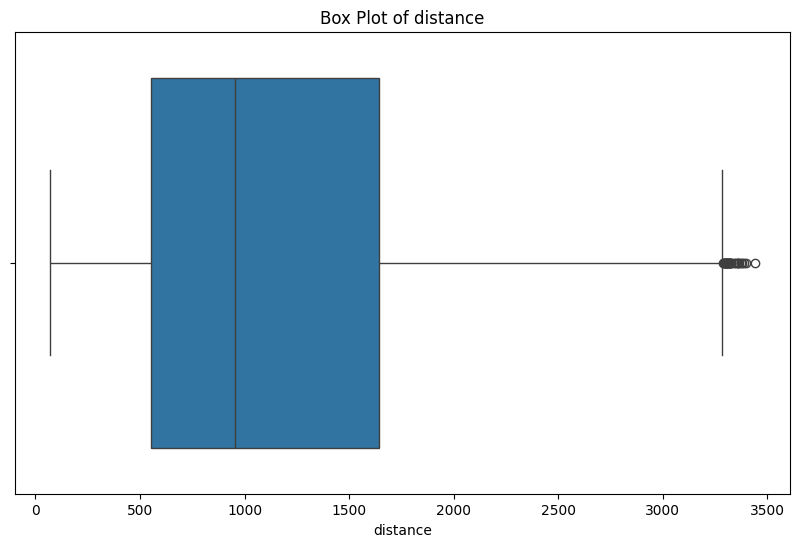

In [270]:
# plot outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=freight['distance'])
plt.title('Box Plot of distance')
plt.show()

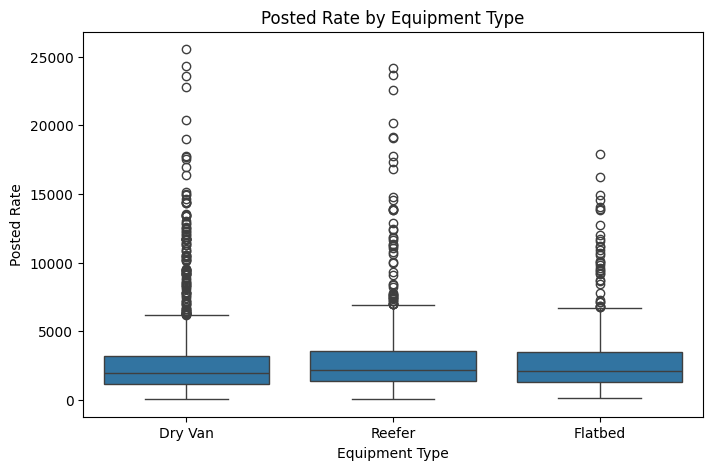

In [271]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=freight, x='equipment', y='posted_rate')
plt.xlabel('Equipment Type')
plt.ylabel('Posted Rate')
plt.title('Posted Rate by Equipment Type')
plt.show()

There seems not to be much of a difference between the type of equipmemt since the median values are almost at the same points and outliers & whisker lengths seem to take up the same pattern

#Exploratory Data Analysis

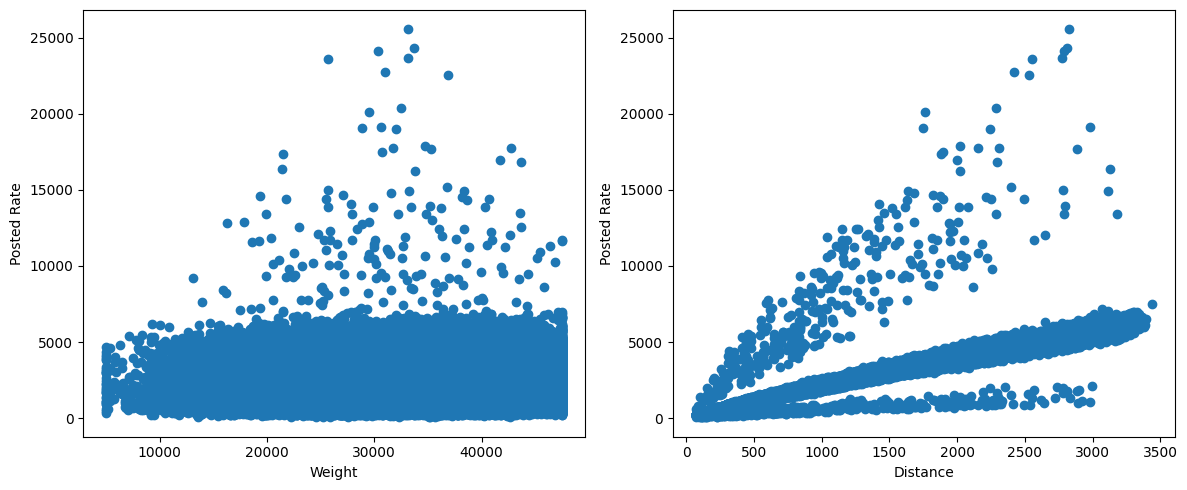

In [272]:
#scatter plot to determine correlation between posted rate vs weight and distance independently

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(freight['weight'], freight['posted_rate'])
axes[0].set_xlabel('Weight')
axes[0].set_ylabel('Posted Rate')

axes[1].scatter(freight['distance'], freight['posted_rate'])
axes[1].set_xlabel('Distance')
axes[1].set_ylabel('Posted Rate')

plt.tight_layout()
plt.show()

Distance seems to have a very high correlation with posted rate -> 0.91. Weight has no particular relation.

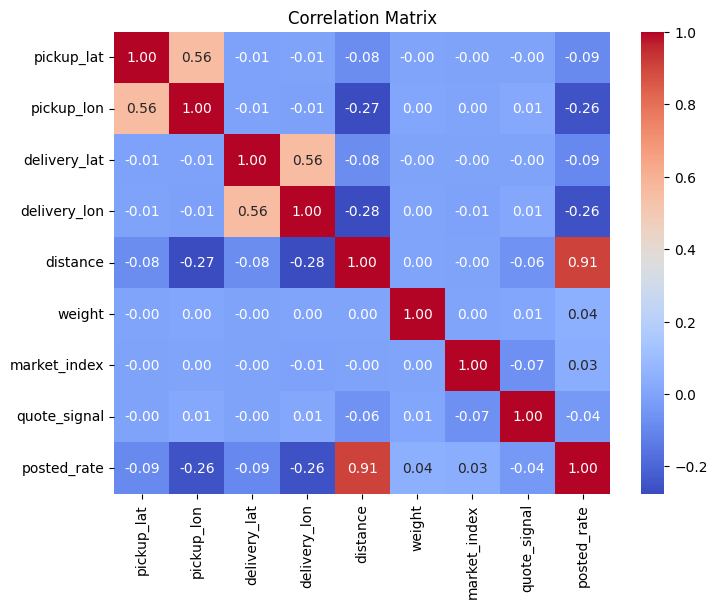

In [273]:
plt.figure(figsize=(8, 6))
sns.heatmap(freight.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

From this heat map it also seems that distance is the only variable that has a correlation to posted rate with market index and weight being the next 2 but very far off.

In [274]:
#Feature engineering to see the average rate per unit distance
freight['rate-distance'] = freight['posted_rate'] / freight['distance']
freight.head(10)

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate,rate-distance
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41,2.352935
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97,2.424135
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54,1.862513
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28,1.892770
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28,2.547112
5,TR-000006,Phoenix,Corpus Christi,28.75668,-115.87725,28.61374,-95.89569,1396.4,Flatbed,17018.0,2025-01-01,0.95167,1.92983,2676.98,1.917058
6,TR-000007,Fresno,San Antonio,33.07921,-119.79528,29.50969,-98.40059,1502.6,Dry Van,19112.0,2025-01-01,0.95696,1.82074,2718.54,1.809224
7,TR-000008,San Francisco,Kansas City,35.19670,-121.69849,39.41104,-91.12450,1976.9,Dry Van,29169.0,2025-01-01,0.97818,1.78430,3522.92,1.782043
8,TR-000009,Bakersfield,Montgomery,33.28832,-116.67935,31.37602,-86.10743,2027.7,Dry Van,35018.0,2025-01-01,0.96534,1.79522,3675.27,1.812531
9,TR-000010,Albuquerque,Phoenix,35.39918,-109.59792,28.75668,-115.87725,717.1,Flatbed,34671.0,2025-01-01,0.98475,2.17079,1578.83,2.201687


The first few rows seem to equate rate per unit distance. We need to investigate further to ensure this is the case

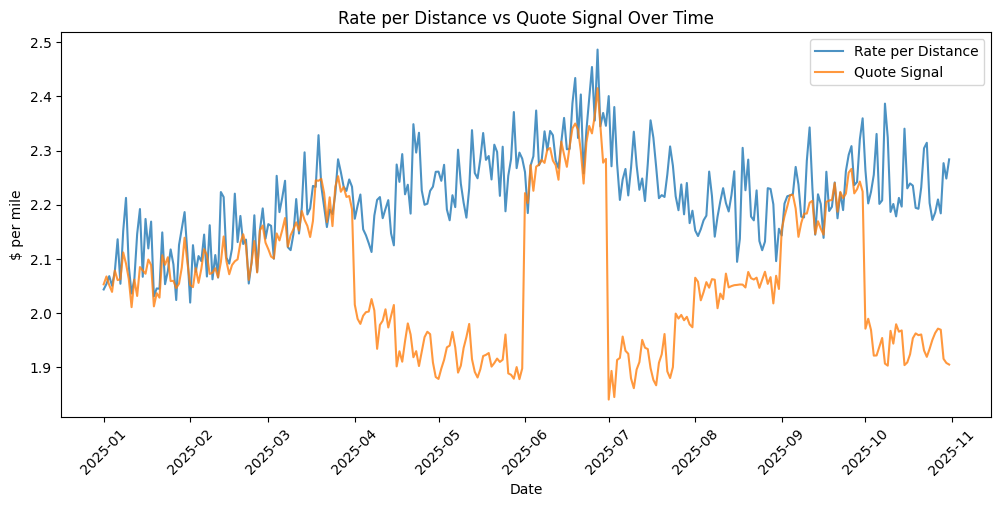

In [275]:
#plotting rate per unit distance against quote signal to check similarity
daily = freight.groupby('date')[['rate-distance', 'quote_signal']].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(daily['date'], daily['rate-distance'], label='Rate per Distance', alpha=0.8)
plt.plot(daily['date'], daily['quote_signal'], label='Quote Signal', alpha=0.8)
plt.xlabel('Date')
plt.ylabel('$ per mile')
plt.title('Rate per Distance vs Quote Signal Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.show()

Qoute signal seems to have the same curve as rate distance upto end of March but differs in the months April & May, July & August and also October.
This variation seems dependent on seasons i.e. hot seasons in the USA,April,May, July, August which reduces the distance and therefore price.

Quote signal should definetely be investigated further to see it's effect on posted rate

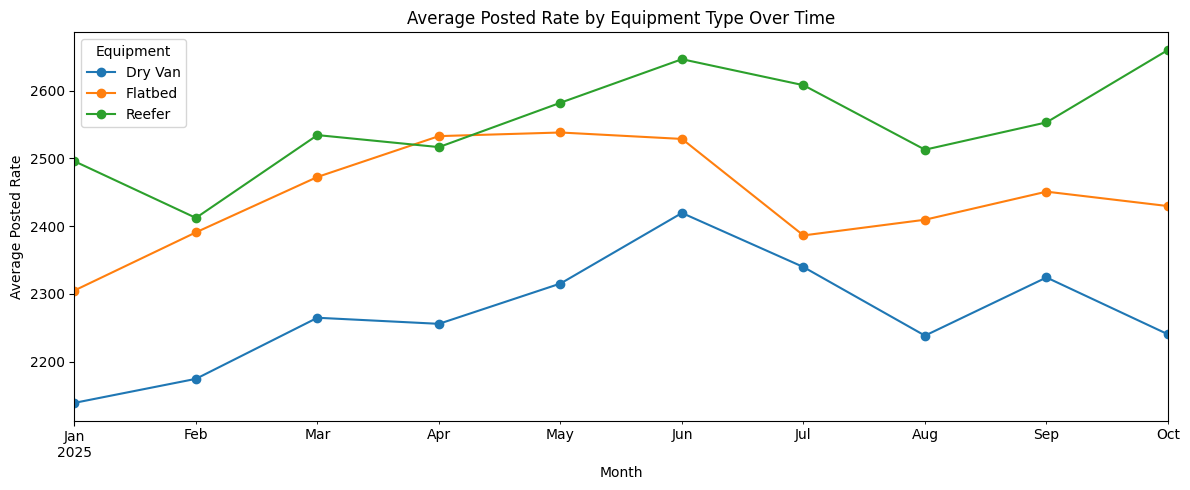

In [276]:
#checking if the equipment type take up the
freight['month'] = freight['date'].dt.to_period('M')
monthly_avg = freight.groupby(['month', 'equipment'])['posted_rate'].mean().unstack()

monthly_avg.plot(figsize=(12, 5), marker='o')
plt.xlabel('Month')
plt.ylabel('Average Posted Rate')
plt.title('Average Posted Rate by Equipment Type Over Time')
plt.legend(title='Equipment')
plt.tight_layout()
plt.show()

The equipment type take the trend of both the distance and quote signal. Both this 2 variables should be considered

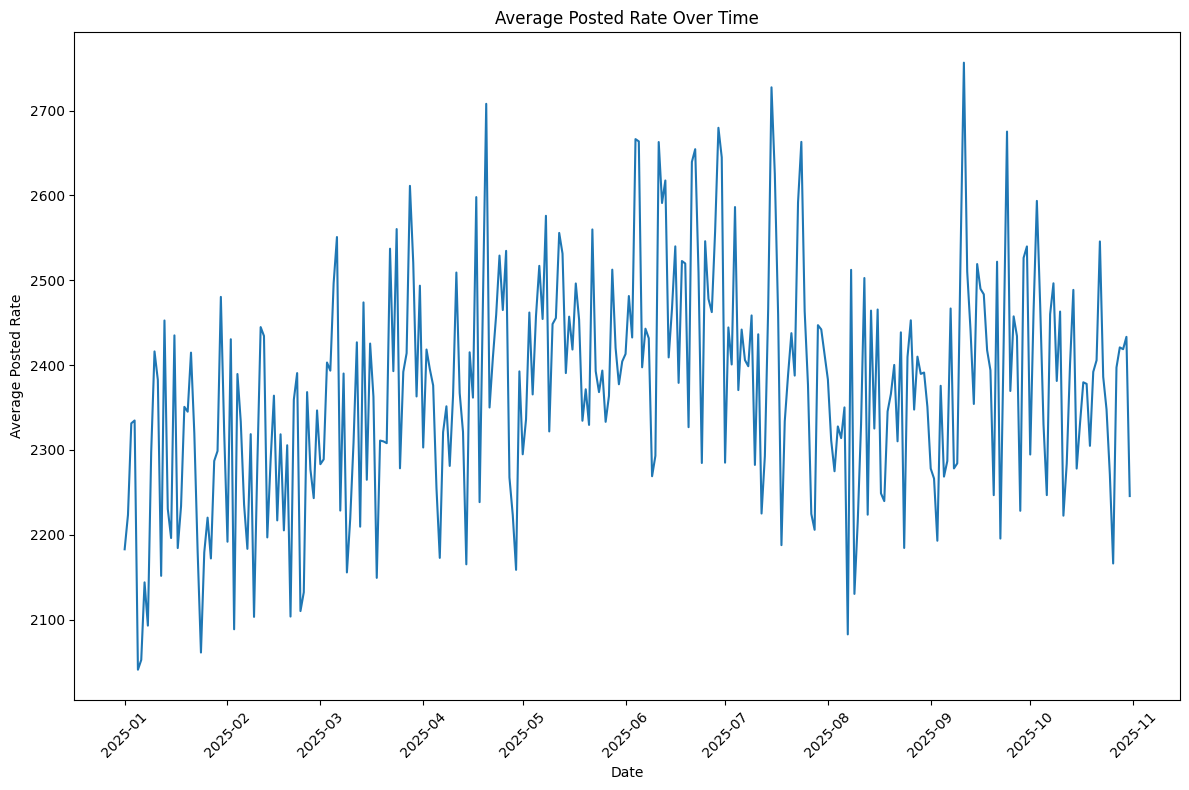

In [277]:
#plotting posted rate against time

freight['date'] = pd.to_datetime(freight['date'])


daily_avg = freight.groupby('date')['posted_rate'].mean()

plt.figure(figsize=(12, 8))
plt.plot(daily_avg.index, daily_avg.values)
plt.xlabel('Date')
plt.ylabel('Average Posted Rate')
plt.title('Average Posted Rate Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

There is significant change in posted rate over time. There seems to be lower values Jan to May, it rises from April to August, falls in September and rises slightly in October. This seems to have taken the trend of rate/distance plotted above.

There seems also to be a rise and fall in prices on a weekly basis that is consistent also in rate-distance as well as quote signal

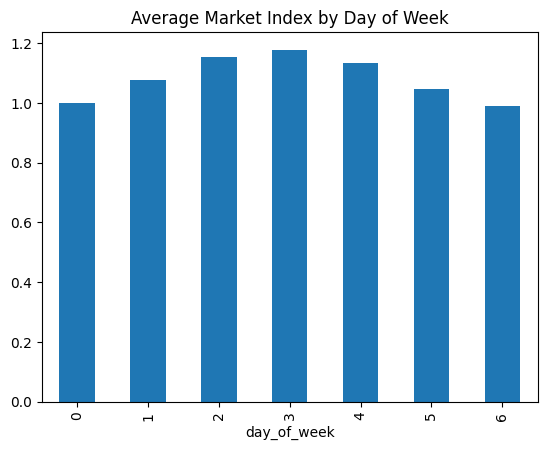

In [278]:
freight['day_of_week'] = freight['date'].dt.dayofweek
freight.groupby('day_of_week')['market_index'].mean().plot(kind='bar')
plt.title('Average Market Index by Day of Week')
plt.show()

This plot explains the movement of posted rate in a week

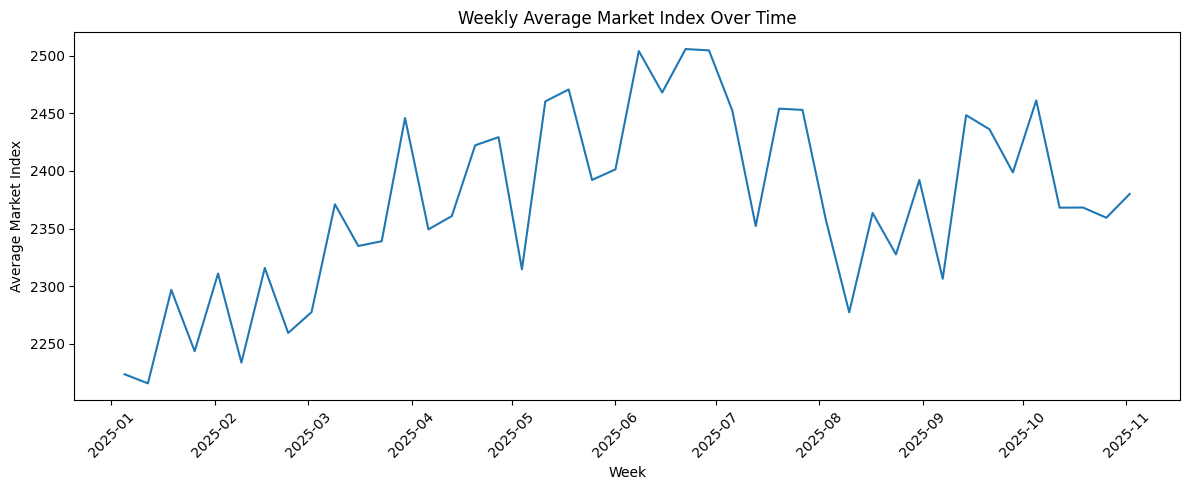

In [279]:
#checking the average movement of posted rate per week
freight['date'] = pd.to_datetime(freight['date'])

weekly_market_index = freight.set_index('date')['posted_rate'].resample('W').mean()

plt.figure(figsize=(12, 5))
plt.plot(weekly_market_index.index, weekly_market_index.values)
plt.xlabel('Week')
plt.ylabel('Average Market Index')
plt.title('Weekly Average Market Index Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This is a better view of the trend seen on average posted rate

In [280]:
dist_mode = freight['distance'].mode()
dist_mode

,distance
0,70.0


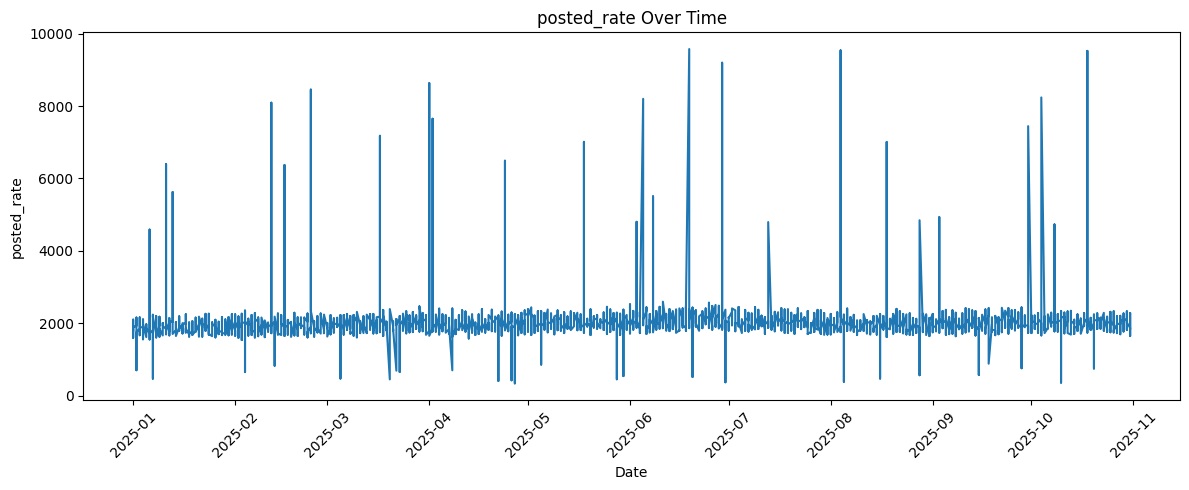

In [281]:
#plotting to see if the trend of posted rate maintains on similar distance around the median
similar_loads = freight[(freight['distance'].between(850, 1000))].copy()
similar_loads = similar_loads.sort_values('date')
similar_loads['posted_rate']
plt.figure(figsize=(12, 5))
plt.plot(similar_loads['date'], similar_loads['posted_rate'])
plt.xlabel('Date')
plt.ylabel('posted_rate')
plt.title('posted_rate Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

It seems as though the trend is not replicated meaning there are other factors that affect the posted rate trend we have seen above. Not just distance.

There seems to be spikes and dips on some days within the month

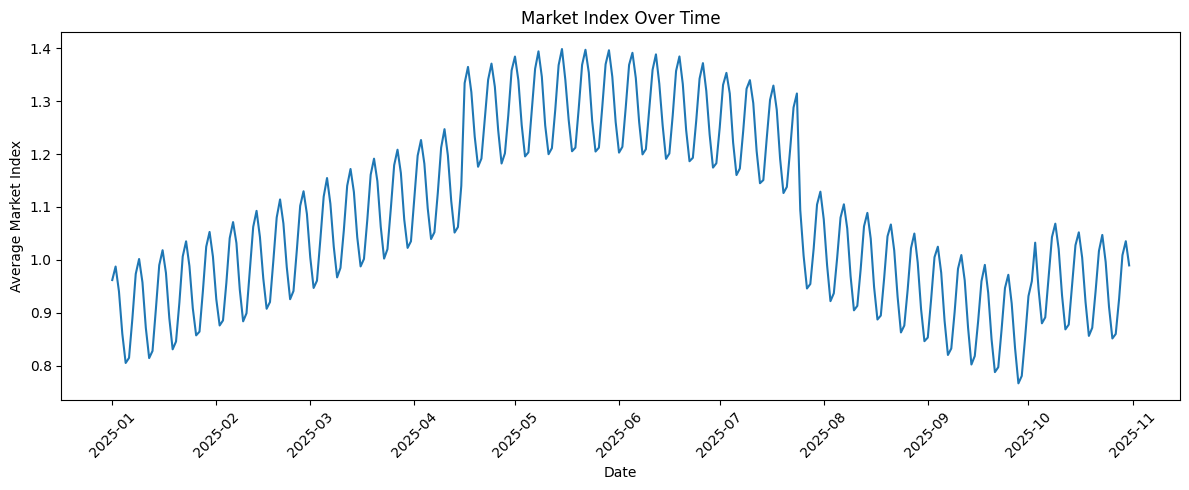

In [282]:
#visualisation of market-index over time
daily_market_index = freight.groupby('date')['market_index'].mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_market_index.index, daily_market_index.values)
plt.xlabel('Date')
plt.ylabel('Average Market Index')
plt.title('Market Index Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Market index seems to have variability over time
It seems to have influence on the posted rate variability over time. since distance is more of a linear relationship as shown in the scatter plot above

In [283]:
daily = freight.groupby('date').agg({
    'posted_rate': 'mean',
    'market_index': 'mean',
    'quote_signal': 'mean'
}).reset_index()

correlation_market = daily['posted_rate'].corr(daily['market_index'])
correlation_quote = daily['posted_rate'].corr(daily['quote_signal'])

print(f"Correlation with market_index: {correlation_market:.4f}")
print(f"Correlation with quote_signal: {correlation_quote:.4f}")

Correlation with market_index: 0.3870
Correlation with quote_signal: 0.0740


market signal seems to have a higher correlation than quote signal

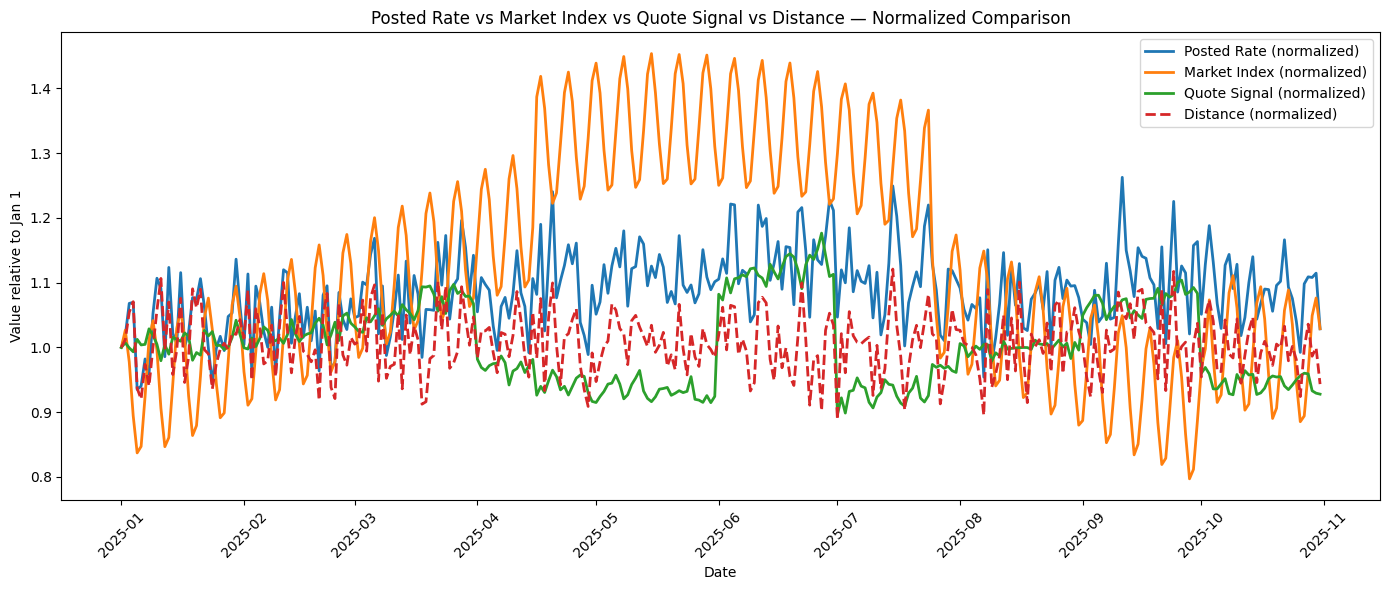

In [284]:
#comparing rate-distance, market index & quote signal correlation with posted rate over time
daily = freight.groupby('date').agg({
    'posted_rate': 'mean',
    'market_index': 'mean',
    'quote_signal': 'mean',
    'distance': 'mean'
}).reset_index()

# Normalize each to start at 1.0 so they're comparable on the same axis
daily['posted_rate_norm'] = daily['posted_rate'] / daily['posted_rate'].iloc[0]
daily['market_index_norm'] = daily['market_index'] / daily['market_index'].iloc[0]
daily['quote_signal_norm'] = daily['quote_signal'] / daily['quote_signal'].iloc[0]
daily['distance_norm'] = daily['distance'] / daily['distance'].iloc[0]

plt.figure(figsize=(14, 6))
plt.plot(daily['date'], daily['posted_rate_norm'], label='Posted Rate (normalized)', linewidth=2)
plt.plot(daily['date'], daily['market_index_norm'], label='Market Index (normalized)', linewidth=2)
plt.plot(daily['date'], daily['quote_signal_norm'], label='Quote Signal (normalized)', linewidth=2)
plt.plot(daily['date'], daily['distance_norm'], label='Distance (normalized)', linewidth=2, linestyle='--')
plt.xlabel('Date')
plt.ylabel('Value relative to Jan 1')
plt.title('Posted Rate vs Market Index vs Quote Signal vs Distance — Normalized Comparison')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Distance tracks the most closest to the posted rate however it does not have the same amplitude on seasonal changes seen on market index and dips seen on quote signal.Therefore it seems absolutely to have the 3 variables used to train the model.
Distance is a linear relationship while market index and quote signal are time variables.
Therefore it would be necessary to have a model that can capture both linear variables as well as time series.
Machine Learning models especially regressors would be the best option since they would be able to identify and predict the complex relationship between linear and time series aspects on the posted rate. Both linear and time series relationships rely heavily on regression

#Feature Selection

In [285]:
#feature importance using Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

features = ['distance', 'weight', 'market_index', 'quote_signal']
X = pd.get_dummies(freight[features + ['equipment']], columns=['equipment'])
y = freight['posted_rate']

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance)

distance             0.875007
quote_signal         0.046348
weight               0.035050
market_index         0.032726
equipment_Dry Van    0.007919
equipment_Reefer     0.001793
equipment_Flatbed    0.001155
dtype: float64


From the above, distance is the highest feature followed by quote signal, weight then market signal. This should then be the features used to model.

Weight had not initially shown a correlation to posted rate but since it is top 4 it needs to be included.

The equipment type shows negligible effect on posted rate. Choosing to leave it helps avoid overfitting of the model

#Modeling

In [286]:
#train- test split
from sklearn.model_selection import train_test_split

cols = ['distance', 'market_index', 'quote_signal', 'weight']

data = freight[['date', 'posted_rate'] + cols].copy()


X =data[cols]
y=data['posted_rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [287]:
#Checking the best Model to adopt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate, KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'mae': 'neg_mean_absolute_error', 'r2': 'r2'}

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}

for name, m in models.items():
    results = cross_validate(m, X, y, cv=kf, scoring=scoring)
    print(f"{name}: MAE = ${-results['test_mae'].mean():.2f} (± ${results['test_mae'].std():.2f}), "
          f"R² = {results['test_r2'].mean():.4f}")

Linear Regression: MAE = $190.81 (± $2.77), R² = 0.8287
Random Forest: MAE = $162.94 (± $1.80), R² = 0.8183
Gradient Boosting: MAE = $156.96 (± $3.26), R² = 0.8338


GBR gives the best output of the 3
Linear Regressor would not be ideal since it will only check the linear correlation of the variables to the output
Between Random Forest and Gradient Boost we are able to select a model that will give better results and by adding additional parameters we will be able to get a better Rsquared value

In [288]:
from sklearn.ensemble import GradientBoostingRegressor

price_model = GradientBoostingRegressor( n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    random_state=42)
price_model.fit(X, y)

GradientBoostingRegressor(learning_rate=0.03, max_depth=4, n_estimators=500,
                          random_state=42, subsample=0.8)

In [289]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = price_model.predict(X_test[cols])

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MAE:  $132.33
RMSE: $489.58
R²:   0.8880
MAPE: 6.32%


Getting an 88% variation explanation of posted rate is a great outcome and may be improved by hyper parameter tuning which we will be done in future for a deployable model.

A mean absolute error of 132 dollars is a good value given the amount ranges upto 25500$. This will be negligible for higher costs

###Cross Validation

In [290]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np


kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scores = -cross_val_score(GradientBoostingRegressor(n_estimators=100,
    learning_rate=0.03,max_depth=4,subsample=0.8,random_state=42), X, y, cv=kf, scoring='neg_mean_absolute_error')
rmse_scores = np.sqrt(-cross_val_score(GradientBoostingRegressor(n_estimators=100,
    learning_rate=0.03,max_depth=4,subsample=0.8,random_state=42), X, y, cv=kf, scoring='neg_mean_squared_error'))
r2_scores = cross_val_score(GradientBoostingRegressor(n_estimators=500,
    learning_rate=0.03,max_depth=4,subsample=0.8,random_state=42), X, y, cv=kf, scoring='r2')

print("MAE per fold: ", np.round(mae_scores, 2))
print(f"Average MAE:  ${mae_scores.mean():.2f} (± ${mae_scores.std():.2f})")

print("\nRMSE per fold:", np.round(rmse_scores, 2))
print(f"Average RMSE: ${rmse_scores.mean():.2f} (± ${rmse_scores.std():.2f})")

print("\nR² per fold:  ", np.round(r2_scores, 4))
print(f"Average R²:   {r2_scores.mean():.4f} (± {r2_scores.std():.4f})")

MAE per fold:  [172.33 174.24 180.16 180.67 174.26]
Average MAE:  $176.33 (± $3.41)

RMSE per fold: [549.83 626.29 635.96 635.16 609.64]
Average RMSE: $611.38 (± $32.20)

R² per fold:   [0.8556 0.8214 0.8187 0.825  0.8335]
Average R²:   0.8308 (± 0.0134)


Cross validation certifies that the model will give consistent model performance and reliable expected outcomes from predictions(across different parameters). rounded to 83%.
We will however use the model that achieved 88% as the prediction model.

In [291]:
#GBR with time as part of columns for modeling
data['month'] = data['date'].dt.month
data['day_of_week'] = data['date'].dt.dayofweek
data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)
data['dow_sin'] = np.sin(2 * np.pi * data['day_of_week'] / 7)
data['dow_cos'] = np.cos(2 * np.pi * data['day_of_week'] / 7)

cols = ['distance', 'weight', 'market_index', 'quote_signal', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']

X_full = data[cols]
y_full = data['posted_rate']

gb_model_final = GradientBoostingRegressor(random_state=42)
gb_model_final.fit(X_full, y_full)

GradientBoostingRegressor(random_state=42)

In [292]:
#metrics on GBR with time aspect
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.3, random_state=42)

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("Train/Test split metrics:")
print(f"  MAE:  ${mae:.2f}")
print(f"  RMSE: ${rmse:.2f}")
print(f"  R²:   {r2:.4f}")
print(f"  MAPE: {mape:.2f}%")


y_train_pred = gb_model.predict(X_train)
print(f"\nTrain MAE: ${mean_absolute_error(y_train, y_train_pred):.2f}")
print(f"Test MAE:  ${mae:.2f}")


kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}
cv_results = cross_validate(GradientBoostingRegressor(random_state=42), X, y, cv=kf, scoring=scoring)

print("\n5-fold cross-validation:")
print(f"  MAE:  ${-cv_results['test_mae'].mean():.2f} (± ${cv_results['test_mae'].std():.2f})")
print(f"  RMSE: ${-cv_results['test_rmse'].mean():.2f} (± ${cv_results['test_rmse'].std():.2f})")
print(f"  R²:   {cv_results['test_r2'].mean():.4f} (± {cv_results['test_r2'].std():.4f})")



Train/Test split metrics:
  MAE:  $152.80
  RMSE: $555.32
  R²:   0.8560
  MAPE: 7.31%

Train MAE: $150.72
Test MAE:  $152.80

5-fold cross-validation:
  MAE:  $156.96 (± $3.26)
  RMSE: $605.62 (± $32.74)
  R²:   0.8338 (± 0.0147)


Gradient Booster Regressor with time aspect has not much difference with the model with the 4 variables; distance, weight, market index, quote signal

#Prediction

In [293]:
#predicting posted rate on validation data set
cols = ['distance', 'market_index', 'quote_signal', 'weight']

X_validation = validation[cols]

validation['predicted_rate'] = price_model.predict(X_validation)

predictions = validation[['load_id', 'predicted_rate']]


output = validation_pred[['load_id']].merge(predictions, on='load_id', how='left')


missing = output['predicted_rate'].isna().sum()
if missing > 0:
    print(f"Warning: {missing} load_id(s) in the template had no matching prediction")


output_path = "validation_predictions.csv"
output.to_csv(output_path, index=False)

print(f"Saved {len(output)} rows to {output_path}")
output.head()

Saved 12000 rows to validation_predictions.csv


,load_id,predicted_rate
0,TE-000001,777.057374
1,TE-000002,4528.879954
2,TE-000003,5664.487113
3,TE-000004,4487.671771
4,TE-000005,1743.298942


In [294]:
#predicting market index and quote signal while comparing with naive or rolling time series models
#these values need to be predicted for the december values which will in turn predict the posted rate
daily = data.groupby('date')[['market_index', 'quote_signal']].mean().reset_index()
daily = daily.sort_values('date').reset_index(drop=True)

def naive_last_value(train, n_days, col):
    return np.full(n_days, train[col].iloc[-1])

def rolling_mean_forecast(train, n_days, col, window=14):
    return np.full(n_days, train[col].tail(window).mean())

daily_split = int(len(daily) * 0.9)
daily_train, daily_test = daily.iloc[:daily_split], daily.iloc[daily_split:]

# market_index candidates
mi_naive = naive_last_value(daily_train, len(daily_test), 'market_index')
mi_rolling = rolling_mean_forecast(daily_train, len(daily_test), 'market_index')

# quote_signal candidates
qs_naive = naive_last_value(daily_train, len(daily_test), 'quote_signal')
qs_rolling = rolling_mean_forecast(daily_train, len(daily_test), 'quote_signal')



In [295]:
from sklearn.metrics import mean_absolute_error

print("market_index:")
print(f"  naive:   MAE = {mean_absolute_error(daily_test['market_index'], mi_naive):.4f}")
print(f"  rolling: MAE = {mean_absolute_error(daily_test['market_index'], mi_rolling):.4f}")

print("quote_signal:")
print(f"  naive:   MAE = {mean_absolute_error(daily_test['quote_signal'], mi_naive):.4f}")
print(f"  rolling: MAE = {mean_absolute_error(daily_test['quote_signal'], mi_rolling):.4f}")


market_index:
  naive:   MAE = 0.1047
  rolling: MAE = 0.0863
quote_signal:
  naive:   MAE = 1.0899
  rolling: MAE = 1.0670


The errors seem small but the either models seem to be performing better on market index rather than quote signal.

Checking to see if other time series models will perform better

In [296]:
#predicting market_index and quote signal from Prophet time series model
from prophet import Prophet
import pandas as pd

def prophet_forecast(daily, n_periods, col, changepoint_prior_scale, yearly=False, weekly=False):
    train_data = daily[['date', col]].rename(columns={'date': 'ds', col: 'y'})
    m = Prophet(yearly_seasonality=yearly, weekly_seasonality=weekly,
                daily_seasonality=False, changepoint_prior_scale=changepoint_prior_scale)
    m.fit(train_data)
    future = m.make_future_dataframe(periods=n_periods)
    forecast = m.predict(future)
    return forecast[['ds', 'yhat']].tail(n_periods).rename(columns={'ds': 'date', col: col, 'yhat': col})

n_periods = 31  # adjust to however many days you're forecasting

# market_index: smooth seasonal pattern
mi_forecast = prophet_forecast(daily, n_periods, 'market_index', changepoint_prior_scale=0.05, yearly=True, weekly=True)

# quote_signal: regime-jump pattern
qs_forecast = prophet_forecast(daily, n_periods, 'quote_signal', changepoint_prior_scale=0.5, yearly=False, weekly=False)

forecast_lookup = mi_forecast.merge(qs_forecast, on='date')
print(forecast_lookup)

         date  market_index  quote_signal
0  2025-11-01      0.911324      1.908145
1  2025-11-02      0.857932      1.903361
2  2025-11-03      0.878432      1.898577
3  2025-11-04      0.962662      1.893792
4  2025-11-05      1.059167      1.889008
5  2025-11-06      1.102383      1.884224
6  2025-11-07      1.071287      1.879439
7  2025-11-08      1.005583      1.874655
8  2025-11-09      0.967118      1.869871
9  2025-11-10      1.002452      1.865087
10 2025-11-11      1.101163      1.860302
11 2025-11-12      1.211536      1.855518
12 2025-11-13      1.267747      1.850734
13 2025-11-14      1.248519      1.845949
14 2025-11-15      1.193312      1.841165
15 2025-11-16      1.163746      1.836381
16 2025-11-17      1.206171      1.831596
17 2025-11-18      1.309983      1.826812
18 2025-11-19      1.423315      1.822028
19 2025-11-20      1.480219      1.817243
20 2025-11-21      1.459332      1.812459
21 2025-11-22      1.400067      1.807675
22 2025-11-23      1.364033      1

In [297]:
#cross validation pf prophet output model
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

def run_prophet_cv(daily, col, changepoint_prior_scale, yearly=False, weekly=False):
    maes = []
    for train_idx, test_idx in tscv.split(daily):
        train_fold = daily.iloc[train_idx][['date', col]].rename(columns={'date': 'ds', col: 'y'})
        test_fold = daily.iloc[test_idx]

        m = Prophet(yearly_seasonality=yearly, weekly_seasonality=weekly,
                    daily_seasonality=False, changepoint_prior_scale=changepoint_prior_scale)
        m.fit(train_fold)

        future = m.make_future_dataframe(periods=len(test_fold))
        forecast = m.predict(future)
        preds = forecast['yhat'].tail(len(test_fold)).values

        maes.append(mean_absolute_error(test_fold[col], preds))
    return maes

# market_index
mi_maes = run_prophet_cv(daily, 'market_index', changepoint_prior_scale=0.05, yearly=True, weekly=True)
print(f"market_index MAE per fold: {np.round(mi_maes, 4)}")
print(f"market_index avg MAE: {np.mean(mi_maes):.4f} (± {np.std(mi_maes):.4f})")

# quote_signal
qs_maes = run_prophet_cv(daily, 'quote_signal', changepoint_prior_scale=0.5, yearly=False, weekly=False)
print(f"\nquote_signal MAE per fold: {np.round(qs_maes, 4)}")
print(f"quote_signal avg MAE: {np.mean(qs_maes):.4f} (± {np.std(qs_maes):.4f})")

market_index MAE per fold: [8.0542 0.3034 0.6021 0.2117 0.1505]
market_index avg MAE: 1.8644 (± 3.0988)

quote_signal MAE per fold: [0.0806 0.3674 0.2439 0.615  0.2515]
quote_signal avg MAE: 0.3117 (± 0.1770)


After cross validation, Prophet model performs better than naive and rolling with an average value of errords 0.3 which is a close to acceptable value but can be improved by trying various models + hyper parameter tuning

In [302]:
from prophet import Prophet
import pandas as pd
import os


def prophet_forecast_for_dates(daily_train_data, target_dates, col, changepoint_prior_scale, yearly=False, weekly=False):
    train_data = daily_train_data[['date', col]].rename(columns={'date': 'ds', col: 'y'})
    m = Prophet(yearly_seasonality=yearly, weekly_seasonality=weekly,
                daily_seasonality=False, changepoint_prior_scale=changepoint_prior_scale)
    m.fit(train_data)


    future = pd.DataFrame({'ds': pd.to_datetime(target_dates)})
    forecast = m.predict(future)
    return forecast[['ds', 'yhat']].rename(columns={'ds': 'date', 'yhat': col})


daily = freight.groupby('date')[['market_index', 'quote_signal']].mean().reset_index()
daily = daily.sort_values('date').reset_index(drop=True)


if december.index.name == 'date':
    december = december.reset_index()


december['date'] = pd.to_datetime(december['date'])


december_dates = sorted(december['date'].unique())

mi_forecast_december = prophet_forecast_for_dates(daily, december_dates, 'market_index', changepoint_prior_scale=0.05, yearly=True, weekly=True)
qs_forecast_december = prophet_forecast_for_dates(daily, december_dates, 'quote_signal', changepoint_prior_scale=0.5, yearly=False, weekly=False)



forecast_lookup_december = mi_forecast_december.merge(qs_forecast_december, on='date', how='left')

# Before merging the new forecast, remove any existing market_index or quote_signal columns
# to prevent pandas from creating suffixed columns (e.g., market_index_x, market_index_y).
if 'market_index' in december.columns:
    december = december.drop(columns=['market_index'])
if 'quote_signal' in december.columns:
    december = december.drop(columns=['quote_signal'])

# Now, merge the forecasted market_index and quote_signal into the december DataFrame.
# This will ensure the columns are added with their correct names.
december = december.merge(forecast_lookup_december[['date', 'market_index', 'quote_signal']], on='date', how='left')


cols = ['distance', 'market_index', 'quote_signal', 'weight']

price_model.fit(X, y)


december['predicted_rate'] = price_model.predict(december[cols])


os.makedirs('data', exist_ok=True)

output_cols = ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
december[output_cols].to_csv("data/december-chart-outputs.csv", index=False)

print(f"Saved {len(december)} December predictions to data/december-chart-outputs.csv")
december[output_cols].head()

Saved 31 December predictions to data/december-chart-outputs.csv


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,1227.726673
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,1223.642459
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,1223.642459
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,1223.642459
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,1223.642459


### Evaluation

The model explains 88% of variation of posted rate with the prophet time series model having a mean absolute error of 0.3. This may be assumed to be high given the small range of figures of the 2 variables - market index and quote signal.

Better outcome can be achieved using
1. hyper parameter tuning
2. more historical data with atleast 2 to 3 years
3. contextual data on seasons and types of goods

Overrally a lot can still be achieved with the provided data.

## Summary

**Project Objectives & Outcomes**


**1. Identify which variables (distance, weight, equipment type, market conditions, date/seasonality) most strongly influence shipping cost.**

Distance, weight, market index and quote signal were identified as the important features that affect pricing, with distance having the highest correlation but affected by seasonal changes


**2. Build a model that accurately predicts December shipping costs based on these variables.**

A combination of Gradient Boost regressors offering 88% accuracy of prediction and a prophet time series model providing time series variable prediction of errors at 0.3 values is a close to accurate figure




## Limitations and Future Recommendations

1. Further hyperparameter tuning could have enhanced the models' performance and improved evaluation metrics.

2. Time required to give output was limited                

3. The dataset did not give a full year cycle therefore the trend may not be accurate. Information about the type of loads shipped would have given the seasonal attributes more meaning and enabled a more informed time series model

In [240]:
!python -m pip install -r requirements.txt.docx

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt.docx'


In [300]:
!python score.py --predictions validation_predictions.csv --december-predictions data/december_chart_inputs.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.
